# Confusion matrix for a configuration

Trains a configuration like `train.py`, but only on `limit_subjects` subjects, and only produces a confusion matrix (no wandb logging, no checkpointing).

In [46]:
import glob
import os
from os.path import join
from pprint import pprint
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import torch
import torchmetrics
import yaml
from torch.utils.data import DataLoader, Subset
from lightning.pytorch import Trainer

from datasets.mmhgdhgr import MultiModalHandGestureDatasetForHandGestureRecognition
from datasets.ml2hp import MotionLeap2Dataset
from datasets.tiny_hgr import TinyHandGestureRecognitionDataset
from model import HandGestureRecognitionModel
from utils import (
    get_device_from_string,
    get_loso_runs,
    get_optimistic_splits,
    get_train_test_splits,
    set_global_seed,
)

In [47]:
# parameters
dataset = "ml2hp"  # one of "ml2hp", "mmhgdhgr", "tiny_hgr"
assert dataset in {"ml2hp", "mmhgdhgr", "tiny_hgr"}
image_backbone_name = "convnextv2-t"
landmarks_backbone_name = "mlp"
limit_subjects = None
max_epochs = 3
seed = 42

matches = glob.glob(
    join("cfgs", dataset, f"{dataset}_loso_{image_backbone_name}_{landmarks_backbone_name}_*.yaml")
)
assert len(matches) == 1, f"expected exactly one match, got {matches}"
cfg_path = matches[0]

num_workers = os.cpu_count()
torch.set_float32_matmul_precision("medium")
set_global_seed(seed=seed)

with open(cfg_path, "r") as fp:
    cfg_dict = yaml.safe_load(fp)
pprint(cfg_dict)

{'accumulate_grad_batches': 1,
 'batch_size': 128,
 'checkpoints_path': './checkpoints/ml2hp',
 'dataset': 'ml2hp',
 'dataset_path': '../../datasets/ml2hp',
 'device': 'auto',
 'image_backbone_name': 'convnextv2-t',
 'landmarks_backbone_name': 'mlp',
 'lr': 5e-05,
 'max_epochs': 3,
 'name': 'ml2hp_loso_convnextv2-t_mlp_hv-images_hv-landmarks',
 'normalize_landmarks': True,
 'seed': 42,
 'train_image_backbone': False,
 'use_horizontal_image': True,
 'use_horizontal_landmarks': True,
 'use_vertical_image': True,
 'use_vertical_landmarks': True,
 'validation': 'loso'}


In [48]:
# sets up the dataset
if cfg_dict["dataset"] == "ml2hp":
    dataset = MotionLeap2Dataset(
        dataset_path=cfg_dict["dataset_path"],
        normalize_landmarks=cfg_dict["normalize_landmarks"],
    )
    dataset.set_mode(
        return_horizontal_images=cfg_dict["use_horizontal_image"],
        return_vertical_images=cfg_dict["use_vertical_image"],
        return_horizontal_landmarks=cfg_dict["use_horizontal_landmarks"],
        return_vertical_landmarks=cfg_dict["use_vertical_landmarks"],
    )
elif cfg_dict["dataset"] == "mmhgdhgr":
    dataset = MultiModalHandGestureDatasetForHandGestureRecognition(
        dataset_path=cfg_dict["dataset_path"],
        normalize_landmarks=cfg_dict["normalize_landmarks"],
        img_size=224,
    )
    dataset.set_mode(
        return_images=any(
            [cfg_dict["use_horizontal_image"], cfg_dict["use_vertical_image"]]
        ),
        return_landmarks=any(
            [cfg_dict["use_horizontal_landmarks"], cfg_dict["use_vertical_landmarks"]]
        ),
    )
elif cfg_dict["dataset"] == "tiny_hgr":
    dataset = TinyHandGestureRecognitionDataset(
        dataset_path=cfg_dict["dataset_path"],
        normalize_landmarks=cfg_dict["normalize_landmarks"],
        img_size=224,
    )
    dataset.set_mode(
        return_images=any(
            [cfg_dict["use_horizontal_image"], cfg_dict["use_vertical_image"]]
        ),
        return_landmarks=any(
            [cfg_dict["use_horizontal_landmarks"], cfg_dict["use_vertical_landmarks"]]
        ),
    )
else:
    raise NotImplementedError()

Parsing samples:  79%|███████▉  | 1129522/1428000 [00:08<00:01, 186411.14it/s]

Error parsing sample for 009, Left_Hand, Two, 1000: _ml2hp_preprocessed/009/Left_Hand/Two/Horizontal/images/1000_right.png does not exist
Error parsing sample for 009, Left_Hand, Two, 1000: _ml2hp_preprocessed/009/Left_Hand/Two/Horizontal/images/1000_right.png does not exist


Parsing samples: 100%|██████████| 1428000/1428000 [00:10<00:00, 142382.09it/s]


In [49]:
# sets up the validation scheme, limited to `limit_subjects` subjects/runs
if cfg_dict["dataset"] == "ml2hp" or cfg_dict["validation"] == "loso":
    runs = get_loso_runs(dataset=dataset, limit_subjects=limit_subjects)
elif cfg_dict["dataset"] in {"mmhgdhgr"}:
    runs = get_train_test_splits(dataset=dataset, limit_subjects=limit_subjects)
elif cfg_dict["dataset"] in {"tiny_hgr"}:
    runs = get_optimistic_splits(dataset=dataset)
else:
    raise NotImplementedError()

print(f"{len(runs)} run(s)")

21 run(s)


In [50]:
# sets up the model
device = get_device_from_string(cfg_dict["device"])
model = HandGestureRecognitionModel(
    num_labels=dataset.num_labels,
    num_landmarks=dataset.num_landmarks,
    img_channels=dataset.img_channels,
    img_size=dataset.img_size,
    image_backbone_name=cfg_dict["image_backbone_name"],
    landmarks_backbone_name=cfg_dict["landmarks_backbone_name"],
    use_horizontal_images=cfg_dict["use_horizontal_image"],
    use_vertical_images=cfg_dict["use_vertical_image"],
    use_horizontal_landmarks=cfg_dict["use_horizontal_landmarks"],
    use_vertical_landmarks=cfg_dict["use_vertical_landmarks"],
    num_epochs=max_epochs,
    lr=cfg_dict["lr"],
)

initial_state_dict_path = "./initial_weights.pth"
torch.save(model.state_dict(), initial_state_dict_path)

In [ ]:
# trains and predicts on every run, accumulating preds/labels across all of them
all_preds, all_labels = [], []
for i_run, run in enumerate(runs):
    run_name = run["subject_id"] if cfg_dict["validation"] == "loso" else f"run_{i_run}"
    print(f"doing run {run_name} ({(i_run + 1) / len(runs) * 100:.1f}%)")

    dataloader_train = DataLoader(
        dataset=Subset(dataset, indices=run["train_idx"]),
        batch_size=cfg_dict["batch_size"],
        shuffle=True,
        pin_memory=False,
        num_workers=num_workers // 2,
        persistent_workers=True,
    )
    dataloader_val = DataLoader(
        dataset=Subset(dataset, indices=run["val_idx"]),
        batch_size=cfg_dict["batch_size"],
        shuffle=False,
        pin_memory=False,
        num_workers=num_workers,
        persistent_workers=True,
    )
    if "test_idx" in run.keys():
        dataloader_test = DataLoader(
            dataset=Subset(dataset, indices=run["test_idx"]),
            batch_size=cfg_dict["batch_size"],
            shuffle=False,
            pin_memory=False,
            num_workers=num_workers,
            persistent_workers=True,
        )
    else:
        dataloader_test = dataloader_val

    # re-initializes the model for this run
    model.load_state_dict(
        torch.load(initial_state_dict_path, map_location=device), strict=False
    )
    model.to(device)

    trainer = Trainer(
        logger=False,
        accelerator=device,
        log_every_n_steps=10,
        precision="16-mixed",
        gradient_clip_val=1.0,
        max_epochs=max_epochs,
        accumulate_grad_batches=cfg_dict["accumulate_grad_batches"],
        enable_model_summary=False,
        enable_checkpointing=False,
    )
    trainer.fit(model, dataloader_train, dataloader_val)

    # collects predictions and labels on the test set
    model.eval()
    model.to(device)
    with torch.no_grad():
        for batch in dataloader_test:
            if "image" in batch:
                if model.use_horizontal_images:
                    batch["image_horizontal"] = batch["image"]
                elif model.use_vertical_images:
                    batch["image_vertical"] = batch["image"]
            if "landmarks" in batch:
                if model.use_horizontal_landmarks:
                    batch["landmarks_horizontal"] = batch["landmarks"]
                elif model.use_vertical_landmarks:
                    batch["landmarks_vertical"] = batch["landmarks"]
            batch.pop("image", None)
            batch.pop("landmarks", None)
            label = batch.pop("label")
            outs = model(**batch)
            all_preds.append(outs["cls_logits"].argmax(dim=1).cpu())
            all_labels.append(label.cpu())
    break

Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

doing run 021 (4.8%)


/home/lanzino/miniconda3/envs/fusionpose/lib/python3.9/site-packages/lightning/pytorch/loops/fit_loop.py:534: Found
170 module(s) in eval mode at the start of training. This may lead to unexpected behavior during training. If this 
is intentional, you can ignore this warning.

In [ ]:
# computes the (aggregated) confusion matrix
confmat = torchmetrics.functional.confusion_matrix(
    preds=torch.cat(all_preds, dim=0),
    target=torch.cat(all_labels, dim=0),
    task="multiclass",
    num_classes=dataset.num_labels,
)
np.save(f"{cfg_dict['dataset']}_cm.npy", confmat.numpy())
confmat

tensor([[421,   0,   0,   0,   0,   0,   0,   0],
        [  0, 445,   0,   0,   0,   0,   0,   0],
        [  0,   0, 389,   0,   0,   0,   0,   0],
        [  2,   0,   0, 372,   1,   0,   0,   0],
        [  0,   0,   0,   0, 419,   0,   0,   0],
        [  0,   0,   0,   0,   0, 443,   0,   0],
        [  0,   0,   0,   0,   0,   0, 438,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0]])

## Plotting

/tmp/ipykernel_23155/3328997083.py:33: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


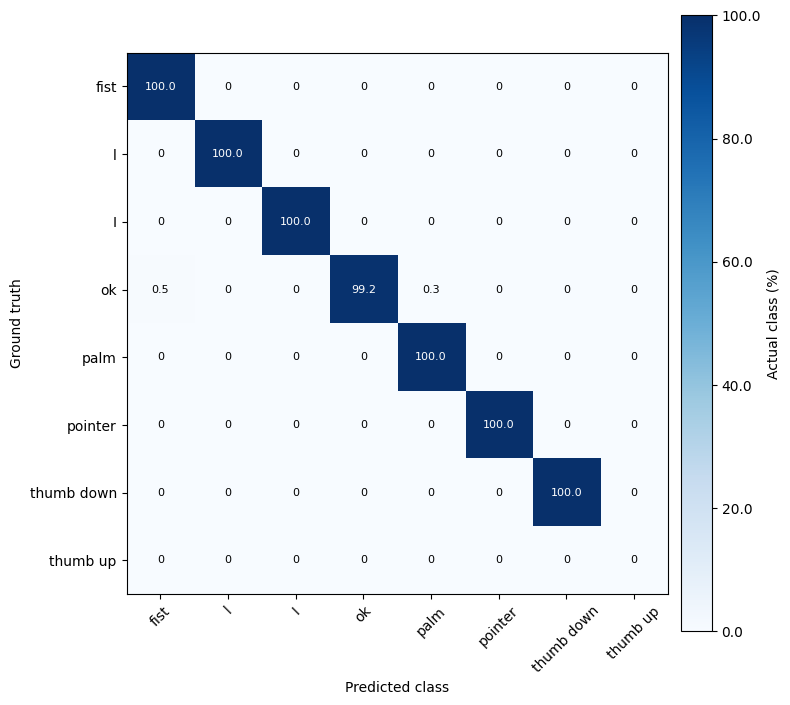

In [ ]:
class_names = [
    name for name, _ in sorted(dataset.poses_dict.items(), key=lambda item: item[1])
]

fig, ax = plt.subplots(figsize=(8, 8), tight_layout=True)
confmat_norm = confmat.float() / confmat.sum(dim=1, keepdim=True).clamp(min=1)
im = ax.imshow(confmat_norm * 100, cmap="Blues", vmin=0, vmax=100)

t = 0  # don't show values under this threshold (%)

for i in range(confmat.shape[0]):
    for j in range(confmat.shape[1]):
        pct = confmat_norm[i, j].item() * 100
        if pct < t:
            continue
        label = "0" if pct == 0 else f"{pct:.1f}"
        ax.text(
            j, i, label,
            ha="center", va="center",
            color="white" if pct > 50 else "black",
            fontsize=8,
        )

ax.set_xticks(range(len(class_names)))
ax.set_yticks(range(len(class_names)))
ax.set_xticklabels(class_names, rotation=45)
ax.set_yticklabels(class_names)
ax.set_xlabel("Predicted class")
ax.set_ylabel("Ground truth")
cbar = fig.colorbar(im, ax=ax, label="Actual class (%)", shrink=0.8, pad=0.02)
cbar.set_ticks([0, 20, 40, 60, 80, 100])
cbar.ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x:.1f}"))
fig.show()
plt.savefig(f"{cfg_dict['dataset']}_confusion_matrix.png", dpi=300)